# Paired multi-model analysis

Here we will use 10X PBMCs scRNA-seq dataset from scanpy as an example to illustrate how Garfield performs scRNA-seq clustering analysis

In [1]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)

gf.__version__

'0.1.2'

In [3]:
rna = sc.read_h5ad('../Garfield_test/data/human_pbmc_10x_3k_RNA.h5ad')
rna.layers['counts'] = rna.X.copy()
rna.obs['batch'] = 'RNA'
atac = sc.read_h5ad('../Garfield_test/data/human_pbmc_10x_3k_ATAC.h5ad')
atac.layers['counts'] = atac.X.copy()
atac.obs['batch'] = 'ATAC'

import pandas as pd
import anndata as ad

# 假设 atac_var_name 是 adata 的一个属性，已经是一个 pandas Series
atac_var_name = atac.var_names  # 假设 var_names 中存储了你需要处理的数据

# 分割每个元素
split_data = atac_var_name.str.split('-', expand=True).to_frame(index=False)
split_data.index = atac_var_name
# 将分割后的数据转换为 DataFrame 并命名列
split_data.columns = ['chr', 'start', 'end']

# 将处理后的 DataFrame 存储到 adata.var 中
atac.var[['chr', 'start', 'end']] = split_data

mdata = MuData({"rna": rna, "atac": atac})
mdata

MuData object with n_obs × n_vars = 2590 × 134920
  var:	'gene'
  2 modalities
    rna:	2590 x 36601
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_peaks', 'nFeature_peaks', 'RNA_snn_res.1', 'seurat_clusters', 'celltype', 'RNA.weight', 'peaks.weight', 'batch'
      var:	'gene'
      layers:	'counts'
    atac:	2590 x 98319
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_peaks', 'nFeature_peaks', 'RNA_snn_res.1', 'seurat_clusters', 'celltype', 'RNA.weight', 'peaks.weight', 'batch'
      var:	'gene', 'chr', 'start', 'end'
      layers:	'counts'

In [4]:
# set workdir
workdir = 'result_garfield_multiome_10xpbmc3k'
gf.settings.set_workdir(workdir)

Saving results in: result_garfield_multiome_10xpbmc3k


In [5]:
gf.settings.set_figure_params(dpi=80,
                              style='white', # style must be one of white, dark, whitegrid, darkgrid, ticks
                              fig_size=[5,5],
                              rc={'image.cmap': 'viridis'})

In [6]:
# make plots prettier
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')

In [7]:
### modify parameter
user_config = dict(
    ## Input options
    data_dir=workdir,  # STR     Location of the dataset to be used.         Default is `data`.
    project_name='multiome_10xpbmc3k',  # STR     Name of the dataset to be used.             Default is `name`.
    adata_list=mdata,  # STR     adata object of single-cell dataset.         Default is `adata`.
    profile='multi-modal',
    data_type='Paired',  # Paired
    weight=0.8,
    genome='hg38',
    sample_col='batch',  # STR     Column name of sample in adata.obs.       Default is `batch`.

    ## Preprocessing options
    rna_n_top_features=2000,
    atac_n_top_features=10000,  # INT     Number of top genes to be selected.       Default is 2000.
    metric='euclidean',  # STR     Metric for clustering.                   Default is `correlation`. euclidean

    ## Model options
    gnn_layer=2,
    hidden_dims=[128, 128],
    svd_q=5,  # default=5, type=int, help='rank'
    cluster_num=20,
    test_split=0.2,
    val_split=0.2,
    used_edge_weight=True,
    used_recon_exp=True,
    used_DSBN=False,
    used_mmd=False,
    batch_size=128,  # INT   batch size of model training
    num_neighbors=[5, 5],
    epochs=50,  # INT       Number of epochs.                        Default is 100.
    mmd_temperature=0.2,  ## mmd regu
    instance_temperature=1.0,
    cluster_temperature=0.5,
    monitor_only_val_losses=False,
    learning_rate=0.001
)
dict_config = gf.settings.set_gf_params(user_config)

In [8]:
## start training
from Garfield.model import GarfieldTrainer
trainer = GarfieldTrainer(dict_config)
trainer.fit()


Preparing dataset...

Data files exist, loading...
Finished loading.

Model training.

 |██████--------------| 32.0%  - epoch_total_loss: 269.1123352051 - epoch_vgae_loss: 7.2007627487 - epoch_instance_loss: 6.9831151962 - epoch_cluster_loss: 2.5840603113 - epoch_recon_loss: 250.2002639771 - epoch_regu_loss: 2144.1386718750 - val_total_loss: 247.7597503662 - val_vgae_loss: 10.7917346954 - val_instance_loss: 6.4351410866 - val_cluster_loss: 2.6284465790 - val_recon_loss: 225.7633666992 - val_regu_loss: 2141.0617675781 - test_roc_auc: 0.9545454545 - test_precision: 0.91666666673

EarlyStopping: run 16 epoch


In [9]:
import scanpy as sc
adata_final = trainer.get_latent_representation()
adata_final

eval mode
Perform get_latent for cells via mini-batch mode


AnnData object with n_obs × n_vars = 2590 × 12000
    obs: 'rna:orig.ident', 'rna:nCount_RNA', 'rna:nFeature_RNA', 'rna:nCount_ATAC', 'rna:nFeature_ATAC', 'rna:nucleosome_signal', 'rna:nucleosome_percentile', 'rna:TSS.enrichment', 'rna:TSS.percentile', 'rna:nCount_peaks', 'rna:nFeature_peaks', 'rna:RNA_snn_res.1', 'rna:seurat_clusters', 'rna:celltype', 'rna:RNA.weight', 'rna:peaks.weight', 'rna:batch', 'rna:n_genes', 'atac:orig.ident', 'atac:nCount_RNA', 'atac:nFeature_RNA', 'atac:nCount_ATAC', 'atac:nFeature_ATAC', 'atac:nucleosome_signal', 'atac:nucleosome_percentile', 'atac:TSS.enrichment', 'atac:TSS.percentile', 'atac:nCount_peaks', 'atac:nFeature_peaks', 'atac:RNA_snn_res.1', 'atac:seurat_clusters', 'atac:celltype', 'atac:RNA.weight', 'atac:peaks.weight', 'atac:batch', 'atac:n_genes'
    var: 'gene', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'neighbors'
    obsm: 'X_gf'
    layers: 

In [9]:
## After pretraining the model can be saved for later use
ref_path = 'reference_model/'
trainer.save(ref_path, overwrite=True)

In [11]:
import dill
import numpy as np
import torch

setup_dict_path = os.path.join(ref_path, "attr.pkl")
model_path = os.path.join(ref_path, "model_params.pt")
varnames_path = os.path.join(ref_path, "var_names.csv")

try:
    with open(setup_dict_path, "rb") as handle:
        attr_dict = dill.load(handle)
# This catches the following error:
# RuntimeError: Attempting to deserialize object on a CUDA device
# but torch.cuda.is_available() is False.
# If you are running on a CPU-only machine, please use torch.load with
# map_location=torch.device('cpu') to map your storages to the CPU.
except RuntimeError:
    with open(setup_dict_path, "rb") as handle:
        attr_dict = UnpicklerCpu(handle).load()

attr_dict
# model_state_dict = torch.load(model_path, map_location=None)

# var_names = np.genfromtxt(varnames_path, delimiter=",", dtype=str)


{'adata_list_': MuData object with n_obs × n_vars = 2590 × 134920
   var:	'gene'
   2 modalities
     rna:	2590 x 36601
       obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_peaks', 'nFeature_peaks', 'RNA_snn_res.1', 'seurat_clusters', 'celltype', 'RNA.weight', 'peaks.weight', 'batch'
       var:	'gene'
       layers:	'counts'
     atac:	2590 x 98319
       obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_peaks', 'nFeature_peaks', 'RNA_snn_res.1', 'seurat_clusters', 'celltype', 'RNA.weight', 'peaks.weight', 'batch'
       var:	'gene', 'chr', 'start', 'end'
       layers:	'counts',
 'atac_n_top_features_': 10000,
 'batch_size_': 128,
 'bottle_neck_neurons_': 20,
 'cluster_num_': 20,
 'cluster_temperature_': 0.5,
 'concat_': True,
 'conv_type_': 

In [18]:
adata_final[adata_final.obs['atac:batch'] == 'ATAC',:].obs['atac:celltype'].value_counts()

atac:celltype
CD14 Mono    735
CD8 Naive    339
CD4 Naive    330
Treg         256
CD4 TCM      235
B cell       199
CD8 TEM      181
CD16 Mono    106
NK            99
cDC2          64
pDC           29
MAIT          17
Name: count, dtype: int64

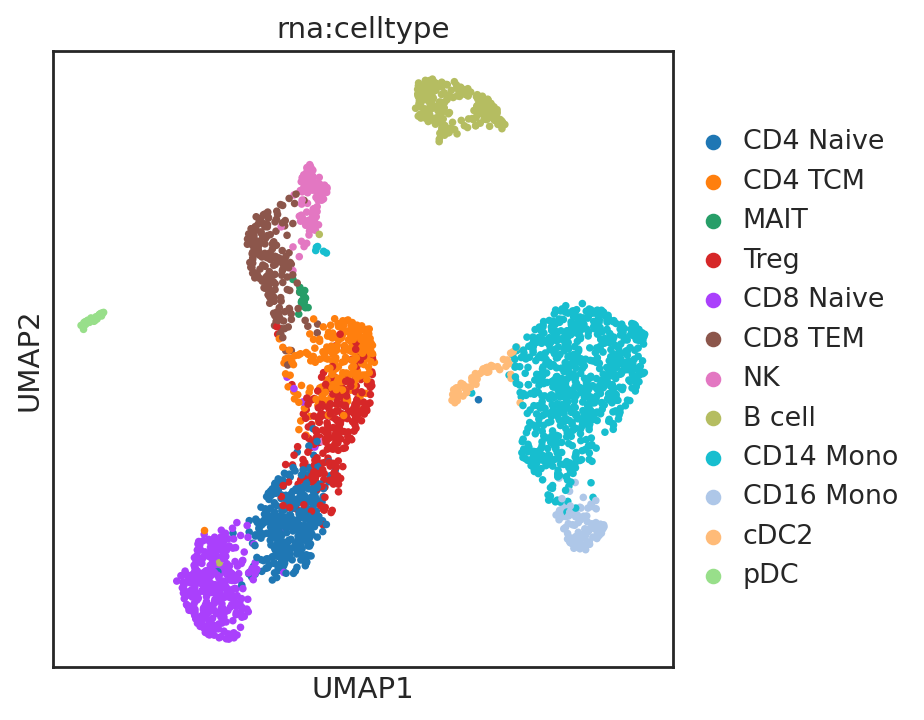

In [11]:
sc.tl.umap(adata_final)

# 创建一个matplotlib的Axes对象并设置背景颜色
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.set_facecolor('white')  # 设置你喜欢的颜色
# adata_final.obs['celltype'] = adata_final.obs['celltype'].astype('category')
sc.pl.umap(adata_final, color=['rna:celltype'], wspace=0.15, edges=False, ax=ax)

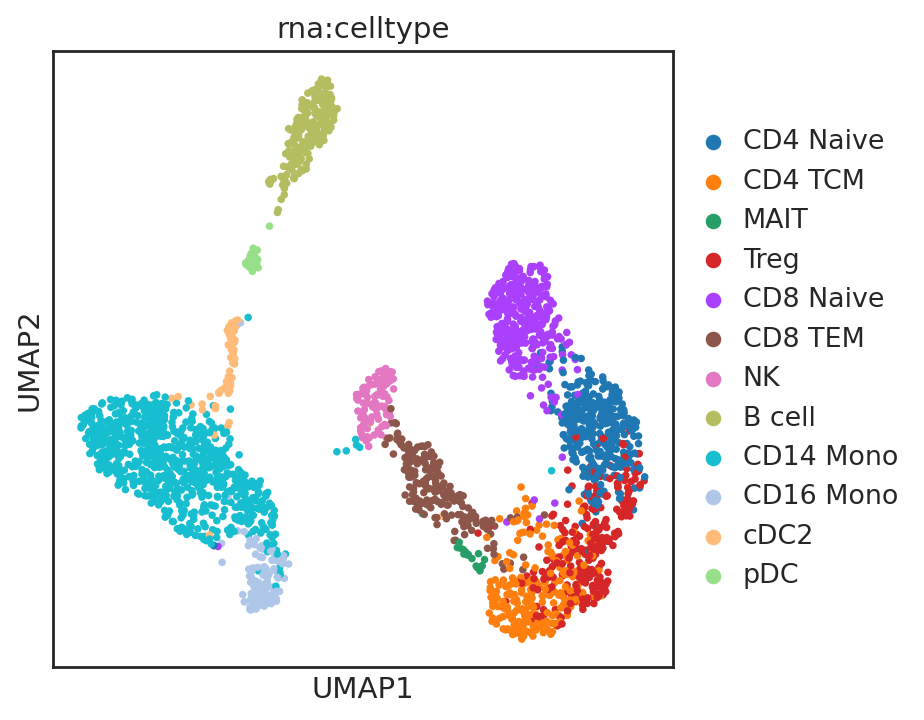

In [10]:
sc.tl.umap(adata_final)

# 创建一个matplotlib的Axes对象并设置背景颜色
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.set_facecolor('white')  # 设置你喜欢的颜色
# adata_final.obs['celltype'] = adata_final.obs['celltype'].astype('category')
sc.pl.umap(adata_final, color=['rna:celltype'], wspace=0.15, edges=False, ax=ax)

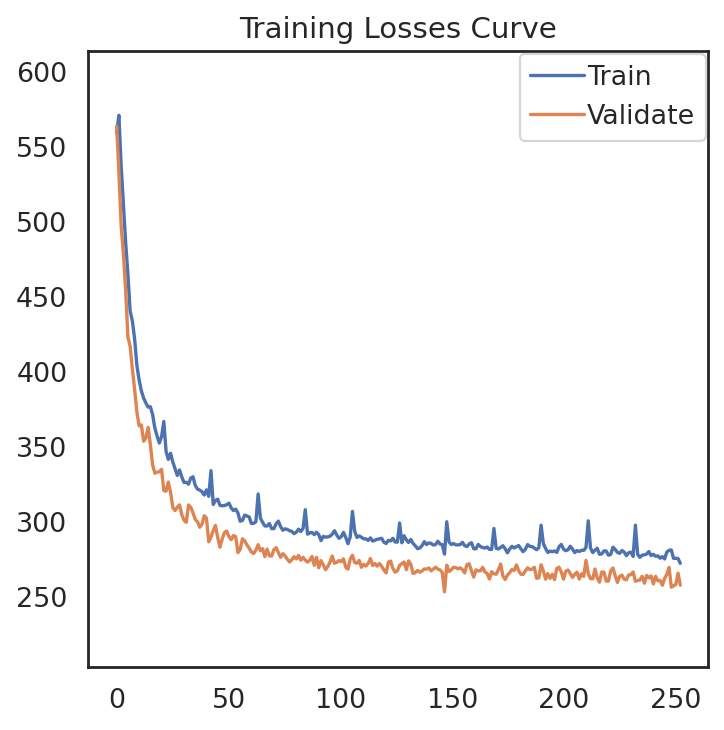

<Figure size 400x400 with 0 Axes>

In [12]:
trainer.plot_losses_curve()

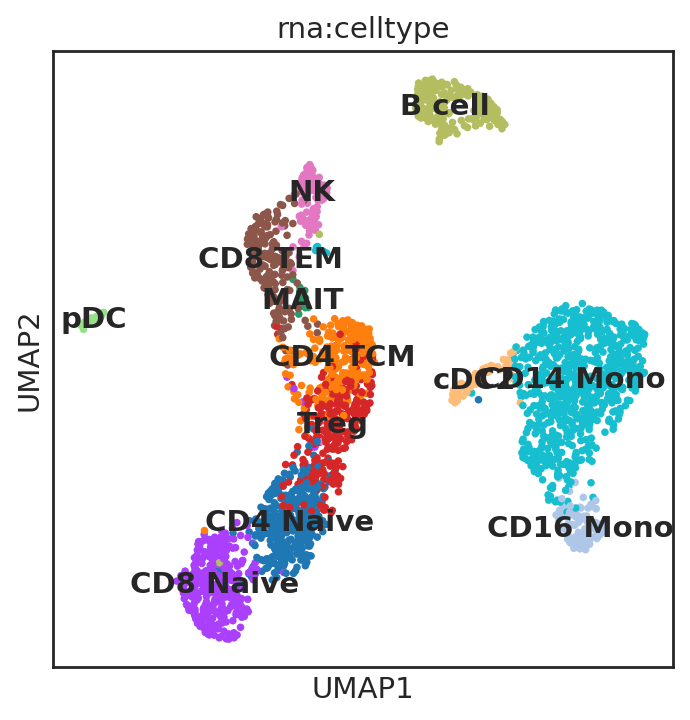

In [13]:
#设置全域sc的画图背景为白色，dpi=50分辨率
# sc.settings.set_figure_params(dpi=80, facecolor="black")

sc.pl.umap(adata_final, color=['rna:celltype'], wspace=0.15, edges=False, legend_loc='on data')

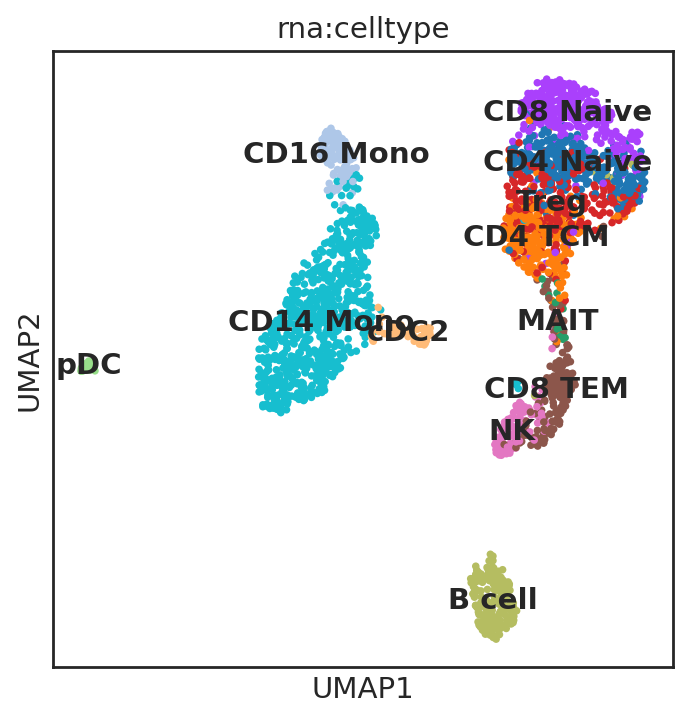

In [29]:
#设置全域sc的画图背景为白色，dpi=50分辨率
# sc.settings.set_figure_params(dpi=80, facecolor="black")

sc.pl.umap(adata_final, color=['rna:celltype'], wspace=0.15, edges=False, legend_loc='on data',save='_pbmc3k_umap.pdf')

In [13]:
sc.tl.leiden(adata_final, resolution=1.0)

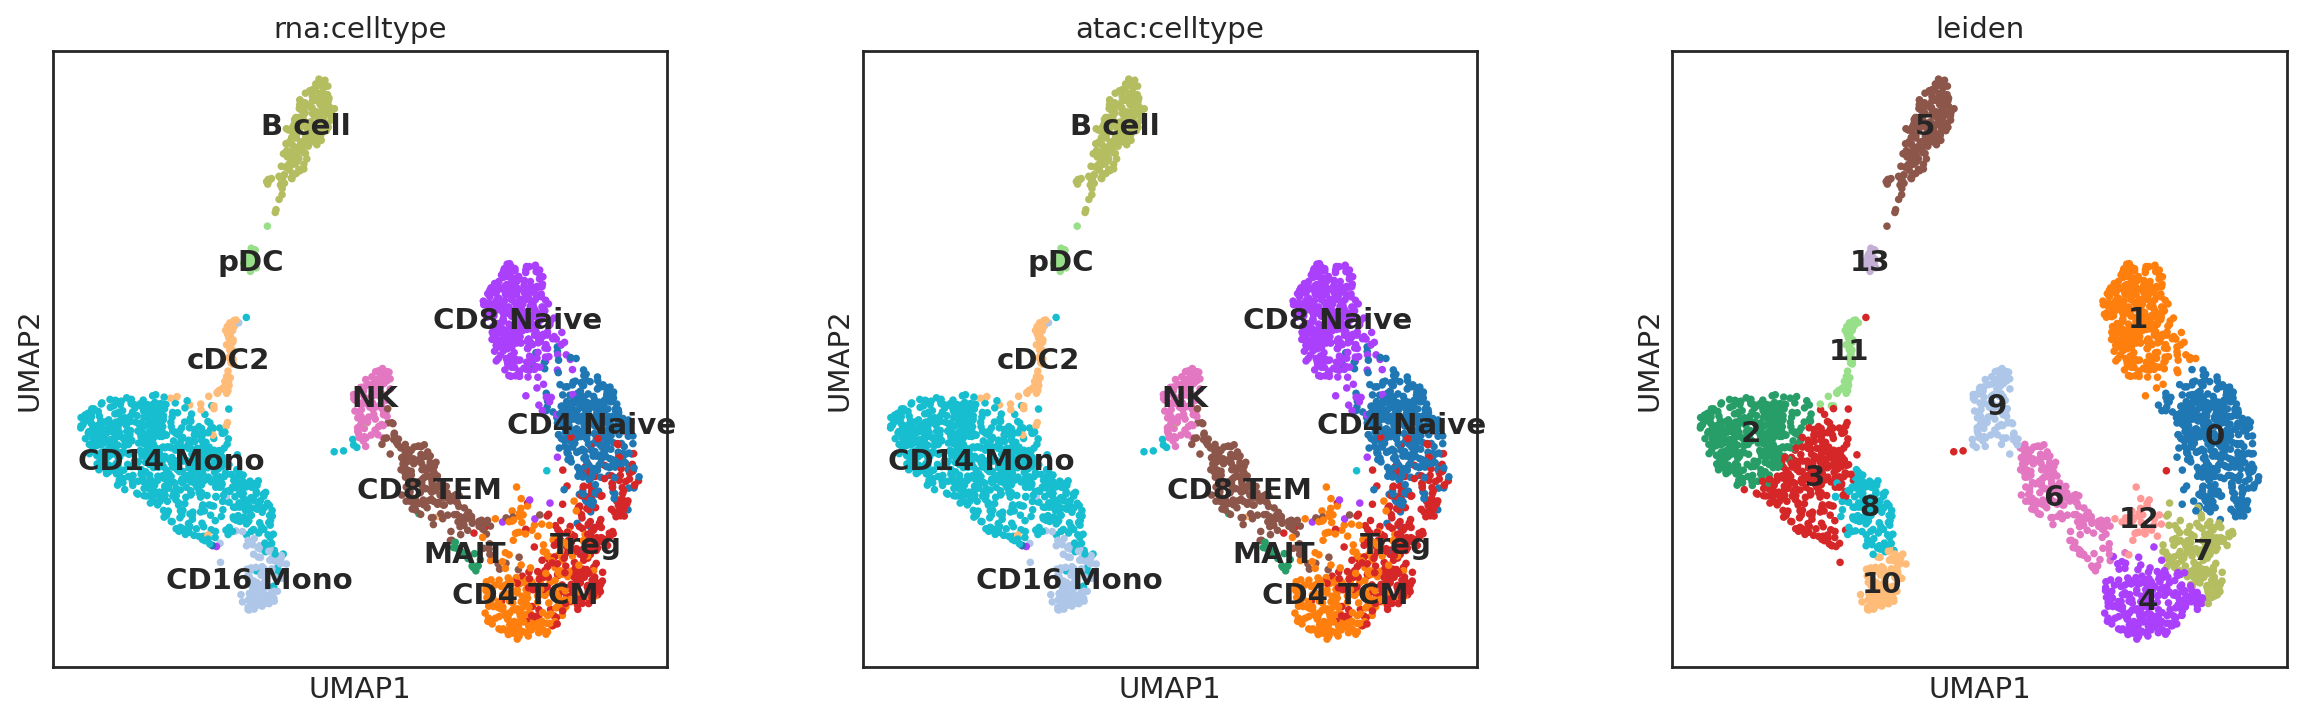

In [14]:
# adata_final.obs['celltype'] = adata_final.obs['louvain']
sc.pl.umap(adata_final, color=['rna:celltype', 'atac:celltype', 'leiden'], wspace=0.20, legend_loc='on data', edges=False, save='_multiome_10xpbmc3k.pdf')

In [ ]:
marker_genes = [
    *["IL7R", "CD79A", "MS4A1", "CD4", "CD8A", "CD8B", "LYZ", "CD14"],
    *["LGALS3", "S100A8", "GNLY", "NKG7", "KLRB1"],
    *["FCGR3A", "MS4A7", "FCER1A", "CST3", "PPBP"],
]
sc.pl.dotplot(adata_final, marker_genes, groupby="celltype",standard_scale='var')
sc.pl.dotplot(adata_final, marker_genes, groupby="leiden", standard_scale='var');

In [3]:
import torch
tmp = torch.load('/data2/zhouwg_data/project/Garfield/result_garfield_multiome_10xpbmc3k/multiome_10xpbmc3k_processed/multiome_10xpbmc3k_merged_adata.pt')
tmp

AnnData object with n_obs × n_vars = 2590 × 12000
    obs: 'rna:orig.ident', 'rna:nCount_RNA', 'rna:nFeature_RNA', 'rna:nCount_ATAC', 'rna:nFeature_ATAC', 'rna:nucleosome_signal', 'rna:nucleosome_percentile', 'rna:TSS.enrichment', 'rna:TSS.percentile', 'rna:nCount_peaks', 'rna:nFeature_peaks', 'rna:RNA_snn_res.1', 'rna:seurat_clusters', 'rna:celltype', 'rna:RNA.weight', 'rna:peaks.weight', 'rna:batch', 'rna:n_genes', 'atac:orig.ident', 'atac:nCount_RNA', 'atac:nFeature_RNA', 'atac:nCount_ATAC', 'atac:nFeature_ATAC', 'atac:nucleosome_signal', 'atac:nucleosome_percentile', 'atac:TSS.enrichment', 'atac:TSS.percentile', 'atac:nCount_peaks', 'atac:nFeature_peaks', 'atac:RNA_snn_res.1', 'atac:seurat_clusters', 'atac:celltype', 'atac:RNA.weight', 'atac:peaks.weight', 'atac:batch', 'atac:n_genes'
    var: 'gene', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    layers: 'counts'
    obsp: 'connectivities'

In [5]:
len(tmp.obsp['connectivities'].data)

3367

In [11]:
import pandas as pd
from scipy.sparse import coo_matrix

# 假设 adata 是已经加载的 AnnData 对象
connectivities = tmp.obsp['connectivities']

# 将稀疏矩阵转换为COO格式，以便提取行列索引和数据值
if not isinstance(connectivities, coo_matrix):
    connectivities = coo_matrix(connectivities)

# 创建数据框
df = pd.DataFrame({
    'source': connectivities.row,  # 源节点索引
    'target': connectivities.col,  # 目标节点索引
    'weight': connectivities.data   # 连接权重
})

print(df.head())

   source  target    weight
0       0    2266  0.880936
1       1    1958  0.501373
2       2    1517  0.778907
3       3     711  0.531048
4       4    1085  0.757737


In [12]:
import pandas as pd

# 假设 df 是你的 DataFrame，tmp 是 AnnData 对象
# 获取 target 和 source 对应的 celltype 数据
celltype_target = tmp[df['target']].obs['rna:celltype'].reset_index(drop=True)
celltype_source = tmp[df['source']].obs['rna:celltype'].reset_index(drop=True)

# 比较两个 Series 对象
matches = celltype_target == celltype_source

# 计算匹配和不匹配的数目
num_matches = matches.sum()
num_mismatches = len(matches) - num_matches

print("Number of matches:", num_matches)
print("Number of mismatches:", num_mismatches)


Number of matches: 2555
Number of mismatches: 812


In [ ]:
import pandas as pd

# Assuming final_cellmatching and rna, atac are defined somewhere in your context
df = pd.DataFrame(list(zip(final_cellmatching[0], final_cellmatching[1], final_cellmatching[2])),
                  columns=['mod1_indx', 'mod2_indx', 'score'])

# Update mod2_indx to shift it by the size of the rna dataframe
df['mod2_indx'] += rna.shape[0]

# Define the full range of indices for both dimensions
all_mod_indices = pd.Index(range(rna.shape[0] + atac.shape[0]))

# Create the first pivot table
pivot_df = df.pivot(index='mod1_indx', columns='mod2_indx', values='score')
pivot_df = pivot_df.reindex(index=all_mod_indices, columns=all_mod_indices).fillna(0.)

# Adjust mod1_indx for the second dataset and create the second pivot table
df['mod1_indx'] += atac.shape[0]
pivot_df2 = df.pivot(index='mod1_indx', columns='mod2_indx', values='score')
pivot_df2 = pivot_df2.reindex(index=all_mod_indices, columns=all_mod_indices).fillna(0.)

# Combine both pivot tables by adding them together
combined_pivot_df = pivot_df.add(pivot_df2, fill_value=0)

# Print or return the combined pivot dataframe
print(combined_pivot_df)


In [12]:
import pandas as pd
import numpy as np

np.random.seed(42)
rna_samples = 10
atac_samples = 8
matches = 15
final_cellmatching = [
    np.random.choice(range(rna_samples), matches, replace=True),  # RNA样本索引
    np.random.choice(range(atac_samples), matches, replace=True),  # ATAC样本索引
    np.random.random(matches) * 100  # 匹配分数
]

rna = pd.DataFrame(index=range(rna_samples))
atac = pd.DataFrame(index=range(atac_samples))

df = pd.DataFrame(list(zip(final_cellmatching[0], final_cellmatching[1], final_cellmatching[2])),
                  columns=['mod1_indx', 'mod2_indx', 'score'])
df2 = df.copy()
df['mod2_indx'] += rna_samples  # 将ATAC索引偏移

all_mod_indices = pd.Index(range(rna_samples + atac_samples))
pivot_df = df.pivot_table(index='mod1_indx', columns='mod2_indx', values='score', aggfunc='mean').reindex(index=all_mod_indices, columns=all_mod_indices).fillna(0.)

df2['mod1_indx'] += atac_samples  # 将RNA索引偏移
pivot_df2 = df2.pivot_table(index='mod1_indx', columns='mod2_indx', values='score', aggfunc='mean').reindex(index=all_mod_indices, columns=all_mod_indices).fillna(0.) # , fill_value=0.

combined_pivot_df = pivot_df.add(pivot_df2, fill_value=0)
print(combined_pivot_df)

           0          1    2          3          4          5    6   \
0    0.000000   0.000000  0.0   0.000000   0.000000   0.000000  0.0   
1    0.000000   0.000000  0.0   0.000000   0.000000   0.000000  0.0   
2    0.000000   0.000000  0.0   0.000000   0.000000   0.000000  0.0   
3    0.000000   0.000000  0.0   0.000000   0.000000   0.000000  0.0   
4    0.000000   0.000000  0.0   0.000000   0.000000   0.000000  0.0   
5    0.000000   0.000000  0.0   0.000000   0.000000   0.000000  0.0   
6    0.000000   0.000000  0.0   0.000000   0.000000   0.000000  0.0   
7    0.000000   0.000000  0.0   0.000000   0.000000   0.000000  0.0   
8    0.000000   0.000000  0.0   0.000000   0.000000   0.000000  0.0   
9    0.000000   0.000000  0.0   0.000000   0.000000   0.000000  0.0   
10   0.000000  45.606998  0.0   0.000000   0.000000  17.052412  0.0   
11  59.241457  29.122914  0.0   0.000000   0.000000   0.000000  0.0   
12   0.000000   0.000000  0.0  13.949386  51.423444   0.000000  0.0   
13   0